### Data Loading and Preparation
This block imports essential libraries, loads the cleaned dataset, splits it into training and testing sets, and applies standard scaling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier 

df_cleaned = pd.read_csv('../data/nasa_cleaned.csv')

X = df_cleaned.drop('Hazardous', axis=1)
y = df_cleaned['Hazardous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Defining the Artificial Neural Network Architecture
Here we designate the structure of our neural network through a centralized function . It allows dynamic configuration of structural properties such as hidden layers, neurons, and dropout rates. We then wrap this Keras logic in a KerasClassifier compatible with Scikit-Learn tools.

In [2]:

def create_model(hidden_layers=1, neurons=32, dropout_rate=0.2):
    model = Sequential()
    
    model.add(Dense(neurons, input_shape=(X_train_scaled.shape[1],), activation='relu'))
    model.add(Dropout(dropout_rate))
    
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

from scikeras.wrappers import KerasClassifier
ann_estimator = KerasClassifier(model=create_model, verbose=0)
print("ANN Architecture defined and wrapped!")

ANN Architecture defined and wrapped!


### Neural Network Hyperparameter Tuning
In this section, we utilize GridSearchCV to explore various valid network properties (depth, width, dropout rate, and training parameters like batch size and epochs), focusing largely on obtaining the highest recall. This step ensures our Artificial Neural Network is optimally tuned before evaluation.

In [3]:

param_grid = {
    'model__hidden_layers': [1, 2],       
    'model__neurons': [16, 32],           
    'model__dropout_rate': [0.2, 0.4],    
    'batch_size': [32, 64],               
    'epochs': [20, 50]                    
}

print("Starting Deep Learning Grid Search... grab a coffee.")

grid_search = GridSearchCV(estimator=ann_estimator, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

best_ann = grid_search.best_estimator_

print(f"\nGrid Search Complete!")
print(f"Best Network Architecture: {grid_search.best_params_}")

Starting Deep Learning Grid Search... grab a coffee.
Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\Edwar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Grid Search Complete!
Best Network Architecture: {'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.2, 'model__hidden_layers': 2, 'model__neurons': 16}


### Evaluation and Visualizations
Finally, we put our best ANN model to the test on the test set. We output the numerical classification report and visually display its performance using a confusion matrix (styled in purple for distinction from the SVM models).

--- ANN Classification Report ---
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       787
        True       0.99      0.96      0.98       151

    accuracy                           0.99       938
   macro avg       0.99      0.98      0.99       938
weighted avg       0.99      0.99      0.99       938



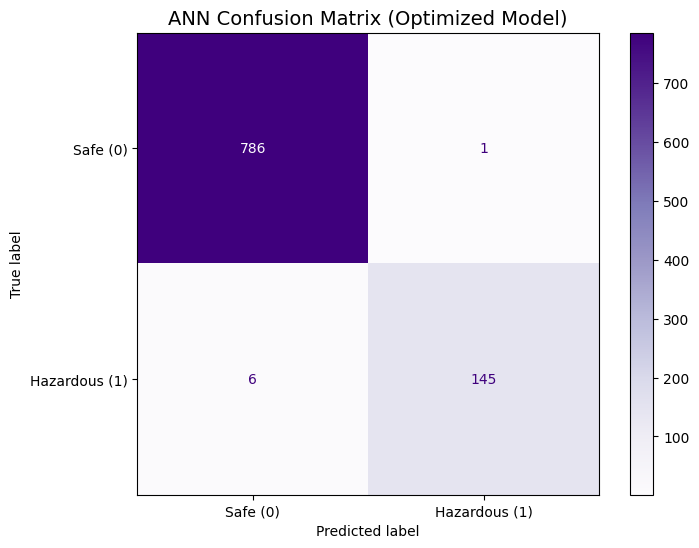

In [4]:

y_pred = best_ann.predict(X_test_scaled)

print("--- ANN Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Hazardous (1)'])

disp.plot(cmap='Purples', values_format='d', ax=plt.gca())

plt.title('ANN Confusion Matrix (Optimized Model)', fontsize=14)
plt.show()